In [1]:
"""Simplified suspension simulation.

MECH 412
J R Forbes, 2022/01/23
Modified 2025/09/22
"""
# %%
# Import packages
import numpy as np
import control
from matplotlib import pyplot as plt

In [2]:
# %%

# Plotting
# Plotting parameters
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif', size=14)
plt.rc('lines', linewidth=2)
plt.rc('axes', grid=True)
plt.rc('grid', linestyle='--')

In [3]:
# %%

# Parameters (do not modify)
m1 = 48.3  # kg, tire mass, unsprung mass
m2 = 395.3  # kg, 1/4 car mass, sprung mass
k1 = 3.4e5  # N / m, tire stiffness
k2 = 30.01e3   # N / m, suspension stiffness
b = 1450  # N s / m, suspension damping

# Stochastic (random) road input parameters for ``smooth" road
nu = 0.2  # rad / m
vx = 27.77  # m / s, forward velocity of the car
rbar = 0.05  # related to the road ``bumps"

In [4]:
# %%

# Transfer function
s = control.tf('s')

G = (k1*(b*s+k2))/(s**4*m1*m2+s**3*b*(m1+m2)+s**2*(m1*k2+m2*k2+m2*k1)+s*(b*k1)+k1*k2)

In [5]:
#%%

# Time (do not modify)
dt = 1e-3
t_start = 0
t_end = 10
t = np.arange(t_start, t_end, dt)

In [6]:
# %%

# Step response

# #### YOU MODIFY - START ####

# You compute the step response
t_step,y_step = control.step_response(G,t)

# #### YOU MODIFY - FINISH ####

In [7]:
# %%

# Random road input (do not modify)
# Gaussian/normal distribution
np.random.seed(584321)
w = np.random.normal(0, rbar / np.sqrt(1000) / np.sqrt(dt), t.size)
R = 1 / (s / nu / vx + 1)  # first-order filter to capture road spectrum
t_r, r = control.forced_response(R, t, w)  # random road profile

In [8]:
# %%

# Forced response

# #### YOU MODIFY - START ####

# You compute the forced response
t_forced, y_forced = control.forced_response(G, t, w)

# #### YOU MODIFY - FINISH ####

In [9]:
# %%

# errors
mu_y = np.mean(y_forced)
sigma_y = np.std(y_forced)
print(f'Mean vehicle height:', mu_y)
print(f'Vehicle height standard deviation: ', sigma_y, '\n')

Mean vehicle height: -1.511416948506175e-05
Vehicle height standard deviation:  0.0063522856544261565 



The mean height is roughly 0 meaning it oscillates evenly about the origin. The standard deviation is 0.006 which is roughly the peak amplitude of the road inputs. 

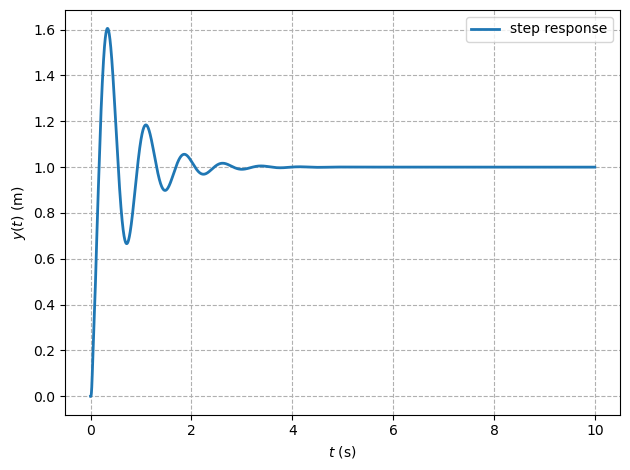

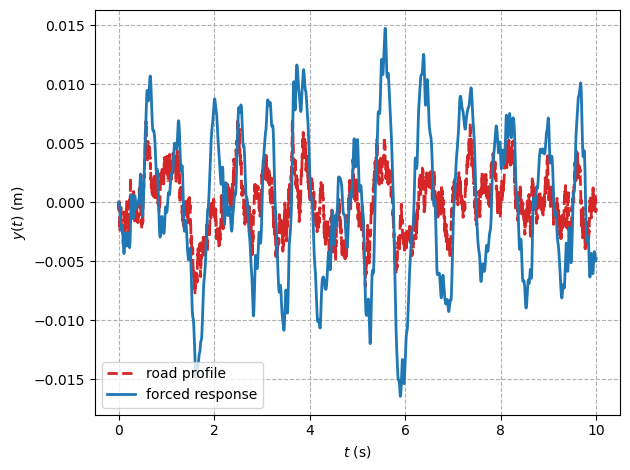

In [10]:
# %%

# Plot

# Plot step response
fig, ax = plt.subplots()
ax.set_xlabel(r'$t$ (s)')
ax.set_ylabel(r'$y(t)$ (m)')
# Plot data
ax.plot(t_step, y_step, label='step response')
ax.legend(loc='upper right')
fig.tight_layout()

# Plot forced response
fig, ax = plt.subplots()
ax.set_xlabel(r'$t$ (s)')
ax.set_ylabel(r'$y(t)$ (m)')
# Plot data
ax.plot(t_r, r, '--', label='road profile', color='C3')
ax.plot(t_forced, y_forced, label='forced response', color='C0')
ax.legend(loc='lower left')
fig.tight_layout()

The forced response is an exaggerated version of the road profile. This simulation leads me to belive the suspension system in this car is designed poorly as the ride wuold be very bumpy and it does not smooth out bumps. 


PART D) simulation allows you to test different suspension parameters such as stiffness and damping to allow you to try to get a smoother ride. I would try reducing stiffness and increasing damping to reduce the large amplitude vibrations.

In [11]:
# %%

# Plot show
plt.show()